# 01 — Energy Data EDA
We inspect demand, PV generation, electricity prices and net load before building the RL agent.

Stage 4.5: regenerated 2023–2025 data, 100 kWp PV. Previous outputs were cleared because the old one-year dataset is obsolete. Run this notebook again for current EDA.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "energy_hourly_2023_2025.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df.head()

,timestamp,demand_kwh,pv_generation_kwh,electricity_price_eur_mwh,electricity_price_eur_kwh,net_load_before_battery_kwh,hour,day_of_week,is_weekend,month,day_of_year
0,2023-01-01 00:00:00,23.502,0.0,98.04,0.09804,23.502,0,6,1,1,1
1,2023-01-01 01:00:00,21.830,0.0,107.18,0.10718,21.830,1,6,1,1,1
2,2023-01-01 02:00:00,28.327,0.0,110.41,0.11041,28.327,2,6,1,1,1
3,2023-01-01 03:00:00,26.068,0.0,109.58,0.10958,26.068,3,6,1,1,1
4,2023-01-01 04:00:00,24.476,0.0,117.96,0.11796,24.476,4,6,1,1,1


## 1. Basic data checks

In [2]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate timestamps:", df.duplicated(subset=["timestamp"]).sum())

Shape: (26304, 11)

Missing values:
timestamp                      0
demand_kwh                     0
pv_generation_kwh              0
electricity_price_eur_mwh      0
electricity_price_eur_kwh      0
net_load_before_battery_kwh    0
hour                           0
day_of_week                    0
is_weekend                     0
month                          0
day_of_year                    0
dtype: int64

Duplicate timestamps: 0


In [3]:
df[["demand_kwh", "pv_generation_kwh", "electricity_price_eur_mwh", "net_load_before_battery_kwh"]].describe().round(2)

,demand_kwh,pv_generation_kwh,electricity_price_eur_mwh,net_load_before_battery_kwh
count,26304.00,26304.00,26304.00,26304.00
mean,45.84,13.55,98.11,32.30
std,15.39,21.92,24.48,18.63
min,13.42,0.00,-25.00,-56.55
25%,31.49,0.00,82.77,26.34
50%,43.47,0.22,96.09,32.70
75%,62.59,18.31,110.76,42.41
max,77.11,100.00,313.07,74.46


## 2. Demand vs PV — example summer week

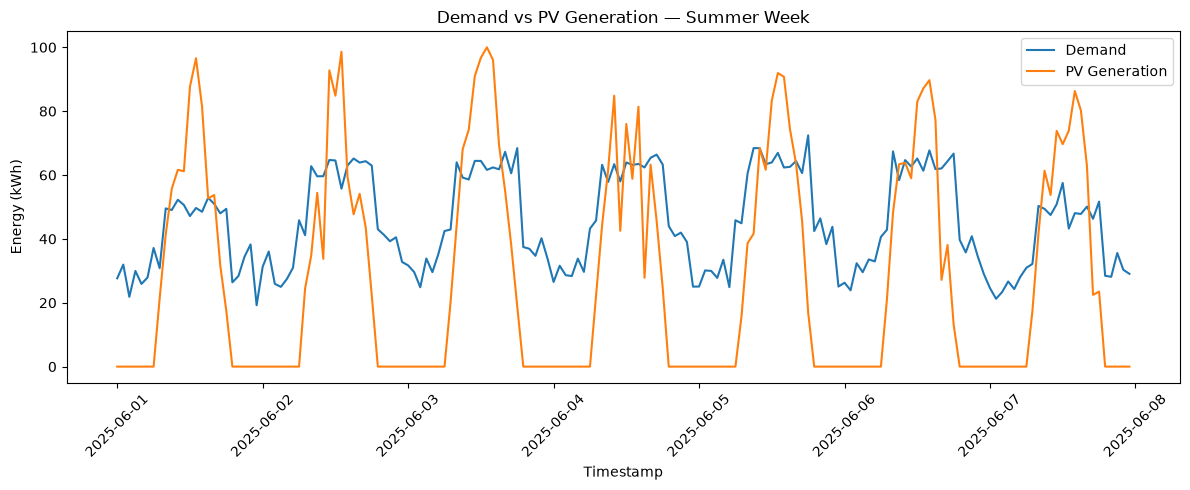

In [4]:
sample = df[(df["timestamp"] >= "2025-06-01") & (df["timestamp"] < "2025-06-08")]

plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["demand_kwh"], label="Demand")
plt.plot(sample["timestamp"], sample["pv_generation_kwh"], label="PV Generation")
plt.title("Demand vs PV Generation — Summer Week")
plt.xlabel("Timestamp")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Average electricity price by hour

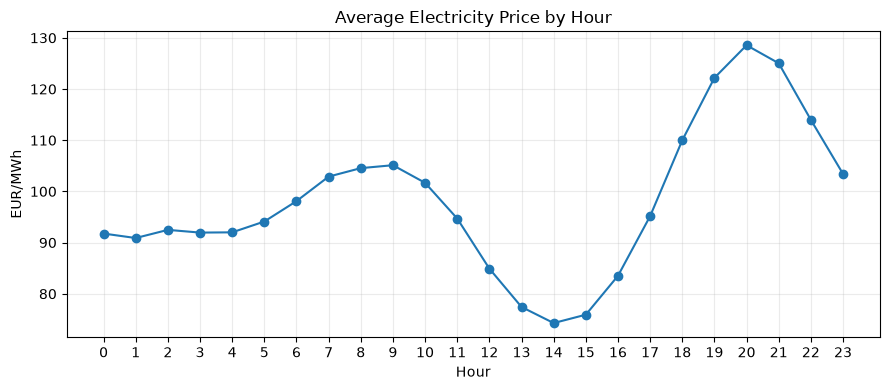

In [5]:
hourly_price = df.groupby("hour", as_index=False)["electricity_price_eur_mwh"].mean()

plt.figure(figsize=(9, 4))
plt.plot(hourly_price["hour"], hourly_price["electricity_price_eur_mwh"], marker="o")
plt.title("Average Electricity Price by Hour")
plt.xlabel("Hour")
plt.ylabel("EUR/MWh")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Average demand and PV profile

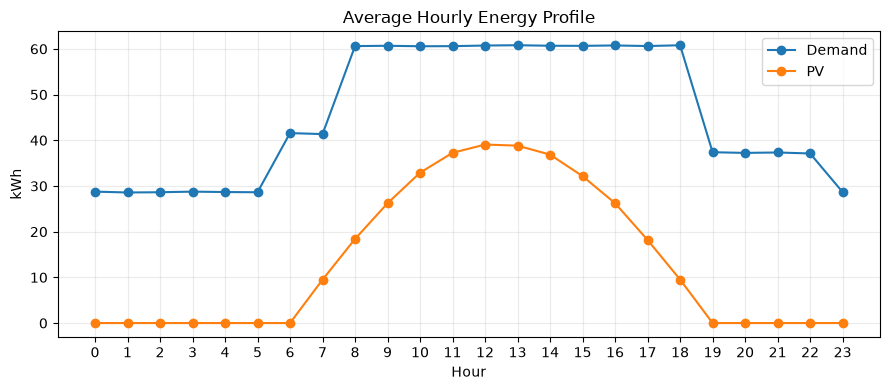

In [6]:
profile = df.groupby("hour", as_index=False)[["demand_kwh", "pv_generation_kwh"]].mean()

plt.figure(figsize=(9, 4))
plt.plot(profile["hour"], profile["demand_kwh"], marker="o", label="Demand")
plt.plot(profile["hour"], profile["pv_generation_kwh"], marker="o", label="PV")
plt.title("Average Hourly Energy Profile")
plt.xlabel("Hour")
plt.ylabel("kWh")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Net load distribution

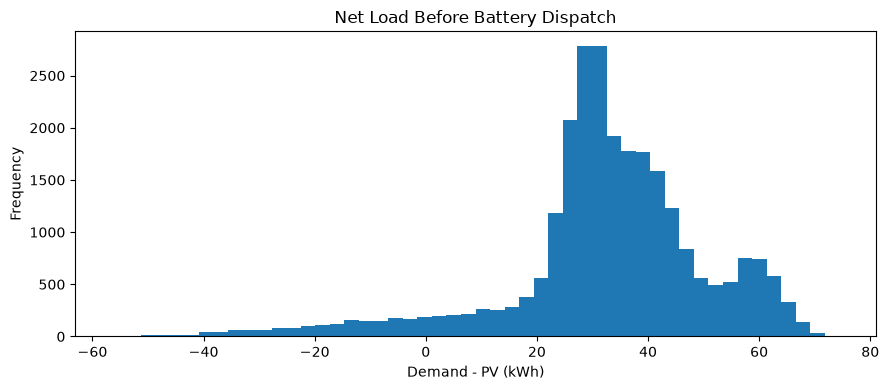

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(df["net_load_before_battery_kwh"], bins=50)
plt.title("Net Load Before Battery Dispatch")
plt.xlabel("Demand - PV (kWh)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Your business interpretation

After running the notebook, write 3–5 bullets answering:
- When is demand highest?
- When is PV generation highest?
- When are prices highest?
- Is there a mismatch between cheap/solar periods and expensive-demand periods?
- Why could a battery create economic value?